# 1.4 Thyroid disease

## 1.4.1 Load datasets

In [38]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import learning_curve
from scipy.io import loadmat
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from  warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

# Loading the datasets
mat = loadmat("thyroidTrain.mat")
X_train = mat["trainThyroidInput"]
y_train = mat["trainThyroidOutput"]
X_test = mat["testThyroidInput"]

print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("\n\033[1mX_train[:10, :10]:\033[0m\n{}".format(X_train[:10,:10])) #first 10 rows and columns
print("\n\033[1my_train[:5]:\033[0m\n{}".format(y_train[:5])) 
print("\n\033[1mX_test[:10, :10]:\033[0m\n{}".format(X_test[:10, :10]))


X_train shape: (5000, 21)
y_train shape: (5000, 3)
X_test shape: (2200, 21)

X_train[:10, :10]:
[[0.28 0.   1.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.45 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.77 0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [0.72 0.   1.   0.   1.   0.   0.   0.   0.   0.  ]
 [0.78 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.74 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.48 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.51 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.45 1.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.46 1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

y_train[:5]:
[[0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 0 1]]

X_test[:10, :10]:
[[0.73 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.6  0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.79 1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.26 0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.71 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.5  1.   1.   0.   0.   0.

# 1.4. 2 Visualization of the data

(5000, 3)
(5000, 2)
(5000,)
(113, 2) (260, 2) (4627, 2)


<IPython.core.display.Javascript object>


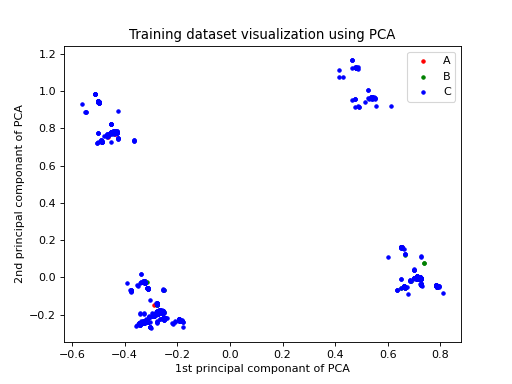

In [2]:
%matplotlib notebook

import matplotlib.pylab as plt
from sklearn.decomposition import PCA

X_pca = PCA(n_components = 2).fit_transform(X_train)
print(y_train.shape)
print(X_pca.shape)
print(np.all(y_train==[0,0,1],axis=1).shape)

X0_pca, X1_pca, X2_pca = X_pca[np.all(y_train==[1,0,0],axis=1)],X_pca[np.all(y_train==[0,1,0],axis=1)],X_pca[np.all(y_train==[0,0,1],axis=1)]
print(X0_pca.shape, X1_pca.shape, X2_pca.shape)

fig, ax = plt.subplots()
ax.scatter(X0_pca[:, 0], X0_pca[:, 1], color = "red", marker=".", label="A")
ax.scatter(X1_pca[:, 0], X1_pca[:, 1], color = "green", marker=".", label="B")
ax.scatter(X2_pca[:, 0], X2_pca[:, 1], color = "blue", marker=".", label="C")

ax.set_xlabel("1st principal componant of PCA")
ax.set_ylabel("2nd principal componant of PCA")
ax.set_title("Training dataset visualization using PCA")
ax.legend()
fig.show()


# 1.4. 3 Feature Selection
Decide the amount/which features are to be used and "discarding" irrelevant features, normalization is required when there are big differences in the ranges of different features which is not in this case, theirfor we are not normalizing the data.


Explained cummulative variance: 
[0.31036517 0.47305845 0.5682959  0.65872494 0.72713443 0.78145833
 0.8292298  0.86294449 0.88628028 0.90862631 0.9294811  0.94855301
 0.96713435 0.9820668  0.99495111 0.99807096 0.99890497 0.99962711
 0.99991214 0.99996986 1.        ]

Explained variance: 
[3.10365172e-01 1.62693274e-01 9.52374546e-02 9.04290340e-02
 6.84094903e-02 5.43239080e-02 4.77714635e-02 3.37146918e-02
 2.33357954e-02 2.23460306e-02 2.08547841e-02 1.90719100e-02
 1.85813377e-02 1.49324564e-02 1.28843058e-02 3.11985427e-03
 8.34003021e-04 7.22146144e-04 2.85027611e-04 5.77160046e-05
 3.01441677e-05]


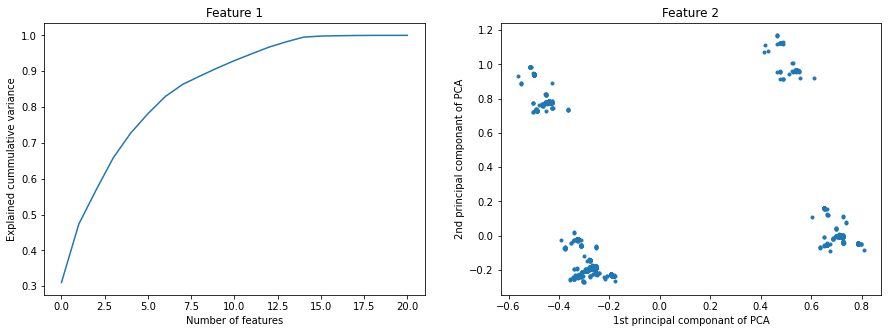

In [16]:
pca = PCA().fit(X_train)
fig1, ax1 = fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax1[0].plot(np.cumsum(pca.explained_variance_ratio_))
print("\n\033[1mExplained cummulative variance:\033[0m \n{}".format(np.cumsum(pca.explained_variance_ratio_)))
print("\n\033[1mExplained variance:\033[0m \n{}".format(pca.explained_variance_ratio_))
ax1[0].set_title('Feature 1')
ax1[0].set_xlabel("Number of features")
ax1[0].set_ylabel("Explained cummulative variance")
X_train_pca = pca.transform(X_train)
ax1[1].scatter(X_train_pca[:,0], X_train_pca[:,1], marker=".")
ax1[1].set_title('Feature 2')
ax1[1].set_xlabel('1st principal componant of PCA')
_ = ax1[1].set_ylabel('2nd principal componant of PCA')

# 1.4. 4 Data normalization
Normalization is required when there are big differences in the ranges of different features which is not in this case, theirfor we are not normalizing the data.

# 1.4. 5 Method and scoring
Here we choose different methods and tune the hyper-parameters with the help of GridSearchCV. After getting the parameters which gave us the best scoring we compare the algorithms to eachother to get the model that predicts the best. The scoring is based on classification error(accuracy). Cross-Validation is done 10-fold.

# 1.4. 5.1 K-Nearest Neighbors


K-NN algorithm is very simple to understand and to implement. Thats the reason why it got chosen as first method to be used in our classfication problem. The nearest neighbors are found based on reading the whole dataset and classifying the new data points. Most of the classifier algorithms are easy to implement for binary problems and needs effort to implement for multi-class whereas K-NN adjust to multi-class without any struggle.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#Parameters to pass in to the grid
param_grid = [{'n_neighbors':list(range(1, 31)),
               'weights':['uniform'],
               'algorithm':['ball_tree', 'kd_tree', 'brute'],
               'leaf_size':[30],
               'p':[1,2,3],
               'metric':['minkowski', 'euclidean', 'manhattan', 'chebyshev', 'seuclidean', 'mahalanobis'],
               'metric_params':[None],
               'n_jobs':[-1]
              }]

# instantiating the model
knn = KNeighborsClassifier()

# Using gridsearch with 10-fold corssvalidation (cv=10) with k-range from 1-31
print('Training the KNN, this might take some time..')
knn_grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=2)

# fit the grid with training data
knn_grid.fit(X_train, y_train)

y_pred=knn_grid.predict(X_test)
# Single best score achieved across all parameters (k)
print ('\n\033[1mSingel best accuracy within k 1 to 30: \033[0m \n{}'.format(grid.best_score_))

# Actual model object fit with those best parameters
knn_clf = knn_grid.best_estimator_

print ('\n\033[1mBest parameters of the KNN are following: \033[0m \n{}'.format(grid.best_params_))
print()

Training the KNN, this might take some time..
Fitting 10 folds for each of 1620 candidates, totalling 16200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 341 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 624 tasks      | elapsed:   30.1s
[Parallel(n_jobs=-1)]: Done 989 tasks      | elapsed:   45.1s
[Parallel(n_jobs=-1)]: Done 1434 tasks      | elapsed:   56.3s
[Parallel(n_jobs=-1)]: Done 1961 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 2568 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 3257 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 7782 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 8633 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 13320 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done 14333 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 15426 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 16200 out of 16


Singel best accuracy within k 1 to 30:  
0.9959999999999999

Best parameters of the KNN are following:  
{'bootstrap': False, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'n_jobs': -1}



## 1.4. 5.2 Evaluation of KNN results
Looking at the result of GridSearchCV from previous section and the learning curve (figure down below), it's somewhat ambiguous and can be miss interpreted, but we got a pretty good score where the margin between the training and cross-validation scores are pretty small +/- 0,008 (0,8%). The modell tend not to overfit neither underfit. 

0.947 (+/- 0.008)


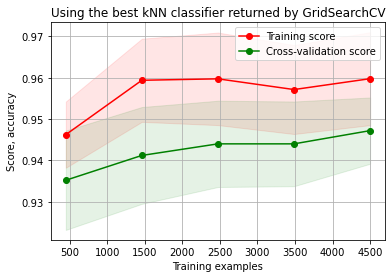

In [29]:
train_sizes, train_scores, test_scores = learning_curve(knn_clf, X_train, y_train, cv=10, scoring='accuracy', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best kNN classifier returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, accuracy")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()

## 1.4 6.1 Random Forest Classifier
It is a skilled and adjustable algorithm and can be used for both regression and classification. It is important when dealing with mulitple features as in our case.

In [19]:
#Parameters to pass in to the grid
param_grid = [{'n_estimators':[100,150,200], 
               'criterion':['gini', 'entropy'],
               'max_depth':[2, 4, 8, None],
               'min_samples_split': [2,3,5,10],
               'max_features':['sqrt', 'log2'],
               'min_samples_leaf':[1, 3, 4, 5],
               'bootstrap':[True, False],
               'n_jobs': [-1],
              }]

rfc = RandomForestClassifier()
print('Training the RFC please be patient, this might take some time...')
rf_grid = GridSearchCV(rfc, param_grid, cv=10, n_jobs=-1, verbose = 2)

# fit the grid with training data
rf_grid.fit(X_train, y_train)

y_pred=rf_grid.predict(X_test)

# Single best score achieved across all parameters
print ('\n\033[1mSingel best score: \033[0m \n{}'.format(grid.best_score_))

# Actual model object fit with those best parameters
rfc_clf =rf_grid.best_estimator_
#Summerize result
print ('\n\033[1mBest parameters of the Random Forest Classifier are following: \033[0m \n{}'.format(grid.best_params_))


Training the RFC please be patient, this might take some time...
Fitting 10 folds for each of 1536 candidates, totalling 15360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 341 tasks      | elapsed:   21.3s
[Parallel(n_jobs=-1)]: Done 624 tasks      | elapsed:   38.8s
[Parallel(n_jobs=-1)]: Done 989 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 1434 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 1961 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2568 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 3257 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 4877 tasks      | elapsed:  5.3min
[Parallel(n_jobs=-1)]: Done 5808 tasks      | elapsed:  6.4min
[Parallel(n_jobs=-1)]: Done 6821 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 7914 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done 9089 tasks      | 


Singel best score:  
0.9959999999999999

Best parameters of the Random Forest Classifier are following:  
{'bootstrap': False, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'n_jobs': -1}


## 1.4 6.2 Evaluation of Random Forest results
Looking at the result of GridSearchCV using the Random Forest classifier, we got even better score compare to K-Nearest Neighbors classifier. Here we attain a margin between the training and cross-validation small +/- 0,003 (0,3%).

0.995 (+/- 0.003)


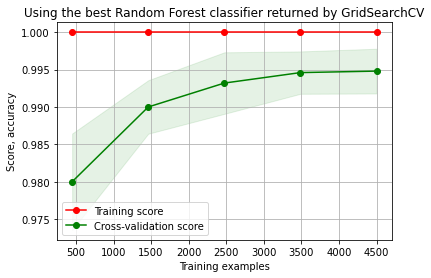

In [30]:
train_sizes, train_scores, test_scores = learning_curve(rfc_clf, X_train, y_train, cv=10, scoring='accuracy', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best Random Forest classifier returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, accuracy")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()



## 1.4 7.1 Multi-layer Perceptron classifier
MLP (Neural networks) are flexible and can be used for both regression and classification problems. Any data which can be made numeric can be used in the model, as neural network is a mathematical model with approximation functions.

In [33]:
#Parameters to pass in to the grid
param_grid1 = [{'hidden_layer_sizes':[(2,3),(8,3,6),(12,15,17),(18,21)], 
               'activation':['identity', 'logistic', 'relu'] ,
               'solver':['lbfgs', 'sgd', 'adam'],
               'alpha': [0.0001, 0.001, 0.01, 1],
               'learning_rate':['constant', 'invscaling', 'adaptive'],
               'max_iter':[5000],
              }]

mlp = MLPClassifier()

mlp_grid = GridSearchCV(mlp, param_grid1, cv=10, n_jobs=-1, verbose = 2)

mlp_grid.fit(X_train, y_train)

y_pred = mlp_grid.predict(X_test)

# Single best score achieved across all parameters
print ('\n\033[1mSingel best Accuracy: \033[0m \n{}'.format(grid.best_score_))

# Actual model object fit with those best parameters
mlp_clf =mlp_grid.best_estimator_
#Summerize result
print ('\n\033[1mBest parameters of the MLP - Classifier are following: \033[0m \n{}'.format(grid.best_params_))

#means = grid.cv_results_['mean_test_score']
#stds = grid.cv_results_['std_test_score']
#params = grid.cv_results_['params']

Fitting 10 folds for each of 432 candidates, totalling 4320 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:   54.1s
[Parallel(n_jobs=-1)]: Done 341 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 624 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 989 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 1434 tasks      | elapsed: 11.3min
[Parallel(n_jobs=-1)]: Done 1961 tasks      | elapsed: 14.8min
[Parallel(n_jobs=-1)]: Done 2568 tasks      | elapsed: 19.1min
[Parallel(n_jobs=-1)]: Done 3257 tasks      | elapsed: 25.0min
[Parallel(n_jobs=-1)]: Done 4026 tasks      | elapsed: 33.7min
[Parallel(n_jobs=-1)]: Done 4320 out of 4320 | elapsed: 37.1min finished



Singel best Accuracy:  
0.9959999999999999

Best parameters of the MLP - Classifier are following:  
{'bootstrap': False, 'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'n_jobs': -1}


c:\users\stanikz\appdata\local\programs\python\python38\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:470: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


## 1.4 7.2 Evaluation of MPL results

0.978 (+/- 0.005)


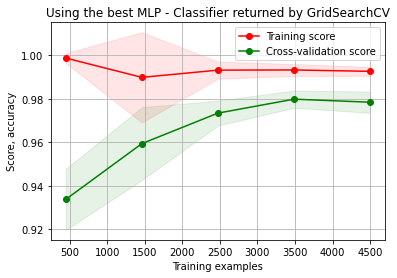

In [34]:
train_sizes, train_scores, test_scores = learning_curve(mlp_clf, X_train, y_train, cv=10, scoring='accuracy', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best MLP - Classifier returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, accuracy")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()